# Spam detection model comparison

Practical assignment for the **Machine Learning** course. This project addresses a
supervised spam email classification problem.

## Dataset

The project uses the [Email Spam Classification Dataset](https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv), available on Kaggle.

## Project Overview

### T1 - Problem Characterization and Spot-Checking

In the first stage, a Python pipeline loads and preprocesses the data, performs
exploratory data analysis, and quickly compares different supervised learning
algorithms. The results are evaluated using appropriate metrics, summarized, and
visualized to identify the most promising models.

The expected outputs are a reproducible Python pipeline, a technical report
describing the problem, methodology, and spot-checking results, and a selection of
2-3 algorithms for further investigation.

### T2 - In-Depth Evaluation

In the second stage, the selected models will be improved through hyperparameter
optimization, more robust evaluation, and statistical analysis. The best model will
also be interpreted to understand its quantitative results and extract insights
about email classification.

The final outputs will be an updated pipeline, a complete report, and an oral
presentation of the project.

# 1. Data downloading

In [20]:
%pip install -q kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balaka18/email-spam-classification-dataset-csv", output_dir="data")

print("Path to dataset files:", path)

100%|██████████| 1.66M/1.66M [00:00<00:00, 1.84MB/s]

Extracting files...
Path to dataset files: data


In [ ]:
from pathlib import Path
import pandas as pd

data_path = Path("src/data/emails.csv")
if not data_path.exists():
    data_path = Path("data/emails.csv")
df = pd.read_csv(data_path)

print(df)


## 1.1 Data summary

Shows data summary, class distribution and total sum of each word (features)

In [23]:
print(f"Rows: {df.shape[0]}")
print(f"Collumns: {df.shape[1]}\n")

print("Data types:")
print(df.dtypes.value_counts())

print("\nMissing values:")
print(df.isna().sum().sum())

#print("\nClass distribution:")
#print(df["Prediction"].value_counts())
#print(df["Prediction"].value_counts(normalize=True).mul(100).round(2))

Rows: 5172
Collumns: 3002

Data types:
int64    3001
str         1
Name: count, dtype: int64

Missing values:
0


In [ ]:
import matplotlib.pyplot as plt

def plot_class_distribution(data: pd.DataFrame | pd.Series, target: str, classes: list,
                            title: str = "Class distribution"):
  labels_data = data if isinstance(data, pd.Series) else data[target]
  class_counts = labels_data.value_counts().sort_index()
  class_labels = {0: classes[0], 1: classes[1]}
  labels = [class_labels.get(value, str(value)) for value in class_counts.index]

  fig, ax = plt.subplots(figsize=(7, 5))
  bars = ax.bar(labels, class_counts.values, color=["#4C78A8", "#F58518"])
  ax.set_title(title)
  ax.set_xlabel("Class")
  ax.set_ylabel("Quantity")
  ax.bar_label(bars, labels=[f"{count} ({count / class_counts.sum():.1%})" for count in class_counts])
  ax.set_ylim(0, class_counts.max() * 1.15)
  plt.tight_layout()
  plt.show()

def plot_feature_frequency(df: pd.DataFrame, features: list[str], n: int):
  if not isinstance(n, int) or n == 0:
    raise ValueError("n must be an integer different from zero")
  if isinstance(features, str) or len(features) == 0:
    raise ValueError("features must contain at least one column name")

  missing_features = [feature for feature in features if feature not in df.columns]
  if missing_features:
    raise ValueError(f"Features not found in df: {missing_features}")

  feature_counts = df.loc[:, list(features)].sum().sort_values(ascending=False)
  non_zero_counts = feature_counts[feature_counts > 0]
  selected = (
    non_zero_counts.nlargest(n) if n > 0
    else non_zero_counts.nsmallest(abs(n))
  ).sort_values(ascending=True)

  fig_height = max(5, len(selected) * 0.32)
  fig, ax = plt.subplots(figsize=(10, fig_height))
  bars = ax.barh(selected.index, selected.values, color="#54A24B")
  ranking = "most frequent" if n > 0 else "least frequent"
  ax.set_title(f"{abs(n)} {ranking} features")
  ax.set_xlabel("Total number of occurrences")
  ax.set_ylabel("Feature")
  ax.bar_label(bars, padding=3)
  ax.set_xlim(0, selected.max() * 1.12)
  plt.tight_layout()
  plt.show()
  return selected

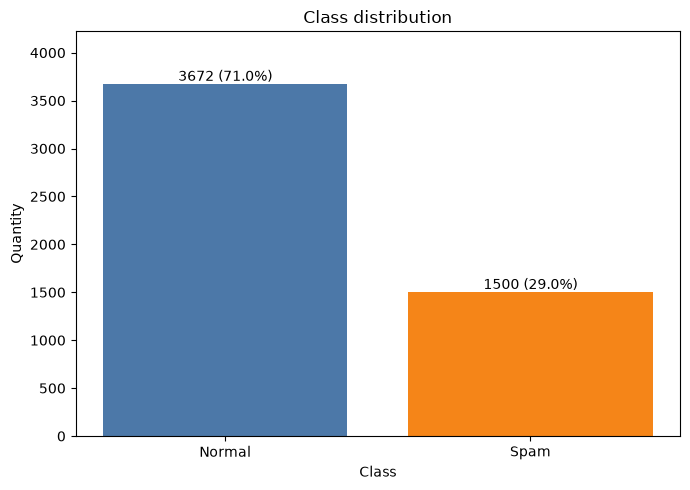

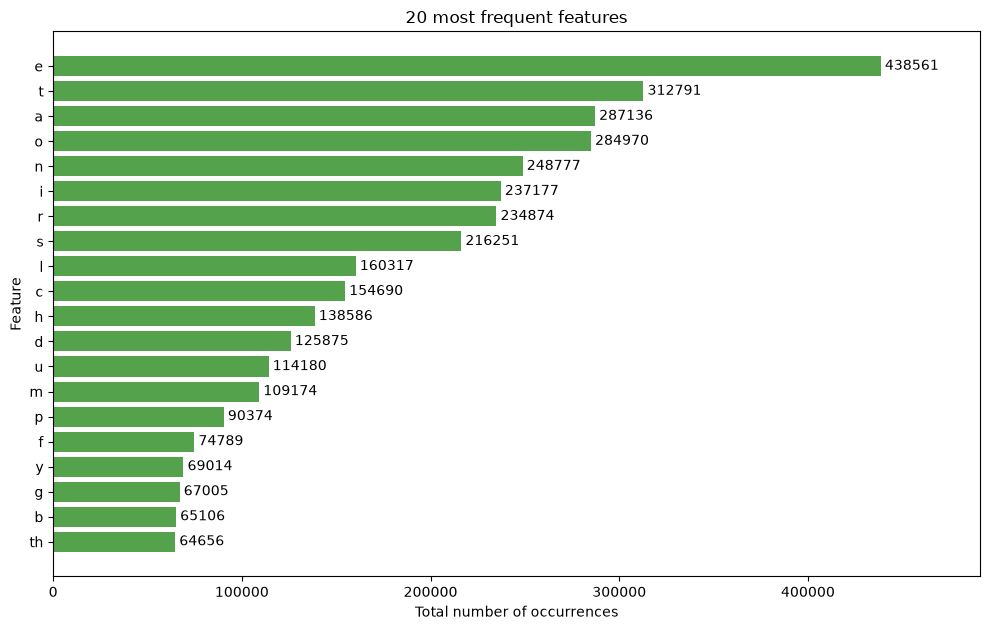

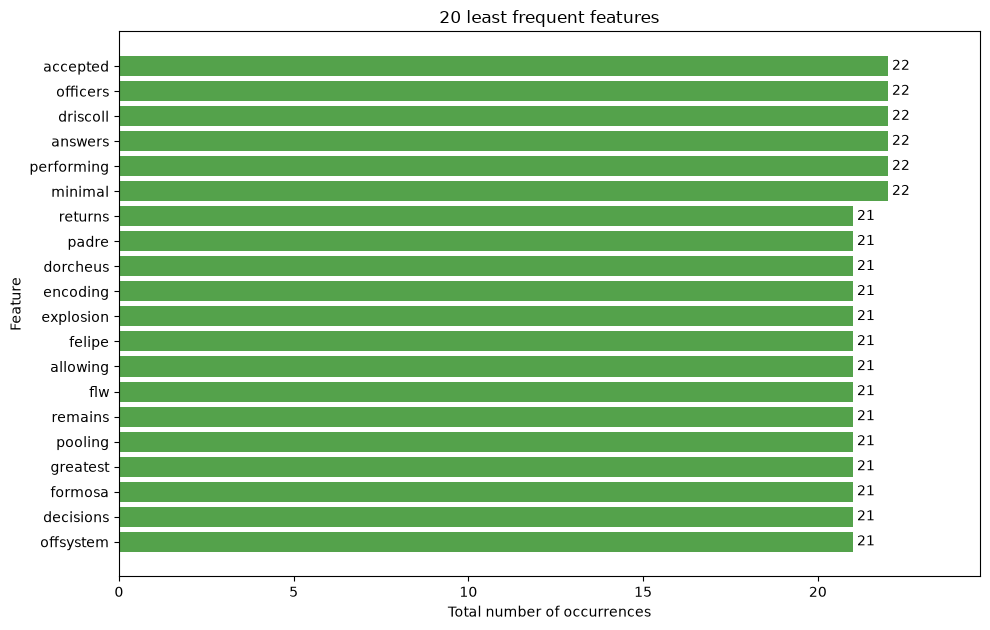

In [26]:
TARGET = "Prediction"
IDENTIFIER = "Email No."
FEATURES = [column for column in df.columns if column not in [IDENTIFIER, TARGET]]

plot_class_distribution(df, TARGET, ['Normal', 'Spam'])

top_n = [20, -20]

for n in top_n:
  plot_feature_frequency(df, FEATURES, n);

## 1.2 Data manipulation & processing 

Removes unacessary features for evaluation and applies normalization

### TF-IDF normalization

Term Frequency-Inverse Document Frequency (TF-IDF) combines the frequency of a word in an email with its inverse document frequency across emails. Words found in many emails receive less weight, while words that are more distinctive retain more weight. With `sublinear_tf=True`, repeated counts are also scaled logarithmically; L2 normalization makes document vectors comparable.

The existing feature matrix contains numeric word counts and is mostly zero, so TF-IDF can weight the observed terms while keeping the representation sparse. We use `TfidfTransformer` because the CSV already supplies word counts. `TfidfVectorizer` would be appropriate for raw email text, which would first need tokenization and counting.

The IDF is learned from the internal training portion of each cross-validation fold. After inspecting the folds, the final transformer is fitted on all of `X_train`; the held-out `X_test` is transformed only and remains untouched during fitting.


In [27]:
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

X = df.drop(columns=["Email No.", "Prediction"])
y = df["Prediction"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

preprocessing = Pipeline([
    ("tfidf", TfidfTransformer(
        norm="l2",
        use_idf=True,
        smooth_idf=True,
        sublinear_tf=True
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_partitions = []
for fold_number, (train_indices, validation_indices) in enumerate(
    cv.split(X_train, y_train), start=1
):
    X_fold_train = X_train.iloc[train_indices]
    X_fold_validation = X_train.iloc[validation_indices]
    y_fold_train = y_train.iloc[train_indices]
    y_fold_validation = y_train.iloc[validation_indices]

    fold_preprocessing = clone(preprocessing)
    X_fold_train_tfidf = fold_preprocessing.fit_transform(X_fold_train)
    X_fold_validation_tfidf = fold_preprocessing.transform(X_fold_validation)

    fold_partitions.append({
        "fold": fold_number,
        "train_rows": len(y_fold_train),
        "validation_rows": len(y_fold_validation),
        "train_matrix_shape": X_fold_train_tfidf.shape,
        "validation_matrix_shape": X_fold_validation_tfidf.shape,
    })

print(f"Train rows: {len(y_train)}; test rows: {len(y_test)}")
print(pd.DataFrame(fold_partitions).to_string(index=False))

# Fit the final preprocessing pipeline only on the full training set.
X_train_tfidf = preprocessing.fit_transform(X_train)
X_test_tfidf = preprocessing.transform(X_test)
print(f"Final TF-IDF matrices: train={X_train_tfidf.shape}, test={X_test_tfidf.shape}")


Train rows: 4137; test rows: 1035
 fold  train_rows  validation_rows train_matrix_shape validation_matrix_shape
    1        3309              828       (3309, 3000)             (828, 3000)
    2        3309              828       (3309, 3000)             (828, 3000)
    3        3310              827       (3310, 3000)             (827, 3000)
    4        3310              827       (3310, 3000)             (827, 3000)
    5        3310              827       (3310, 3000)             (827, 3000)
Final TF-IDF matrices: train=(4137, 3000), test=(1035, 3000)


In [ ]:
plot_class_distribution(y_train, TARGET, ['Normal', 'Spam'],
                        title="Training class distribution")
plot_class_distribution(y_test, TARGET, ['Normal', 'Spam'],
                        title="Test class distribution")
